In [1]:
!pip install pandas numpy textblob matplotlib seaborn

In [2]:
import pandas as pd
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = [
    "AI is transforming the future in a great way!",
    "I hate how AI is replacing human jobs.",
    "AI is okay but still needs improvement.",
    "This AI tool is absolutely fantastic!",
    "Not impressed with AI performance.",
    "AI is neutral for me right now.",
    "Amazing advancements in Artificial Intelligence!",
    "AI results are disappointing sometimes.",
    "I love working with AI technologies.",
    "AI is confusing but interesting."
]

df = pd.DataFrame(data, columns=["Tweets"])
df.head()

,Tweets
0,AI is transforming the future in a great way!
1,I hate how AI is replacing human jobs.
2,AI is okay but still needs improvement.
3,This AI tool is absolutely fantastic!
4,Not impressed with AI performance.


In [5]:
def clean_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # remove mentions
    text = re.sub(r'#', '', text)              # remove hashtags
    text = re.sub(r'RT[\s]+', '', text)        # remove RT
    text = re.sub(r'https?:\/\/\S+', '', text) # remove links
    return text

df["Clean_Tweets"] = df["Tweets"].apply(clean_text)


In [6]:
def analyze_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score == 0:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Clean_Tweets"].apply(analyze_sentiment)

In [7]:
print(df)
print("\nSentiment Count:\n")
print(df["Sentiment"].value_counts())

                                             Tweets  \
0     AI is transforming the future in a great way!   
1            I hate how AI is replacing human jobs.   
2           AI is okay but still needs improvement.   
3             This AI tool is absolutely fantastic!   
4                Not impressed with AI performance.   
5                   AI is neutral for me right now.   
6  Amazing advancements in Artificial Intelligence!   
7           AI results are disappointing sometimes.   
8              I love working with AI technologies.   
9                  AI is confusing but interesting.   

                                       Clean_Tweets Sentiment  
0     AI is transforming the future in a great way!  Positive  
1            I hate how AI is replacing human jobs.  Negative  
2           AI is okay but still needs improvement.  Positive  
3             This AI tool is absolutely fantastic!  Positive  
4                Not impressed with AI performance.  Negative  
5         

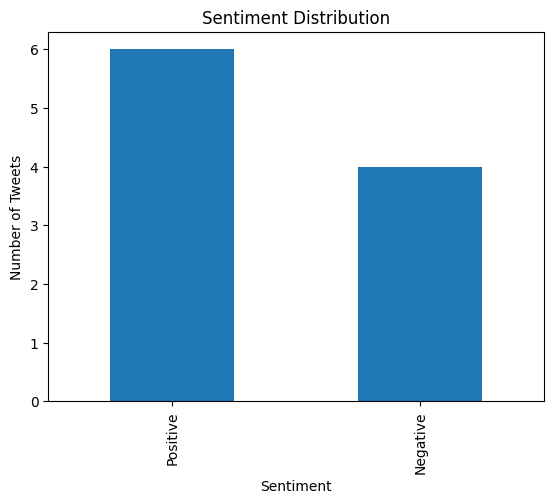

In [8]:
df["Sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

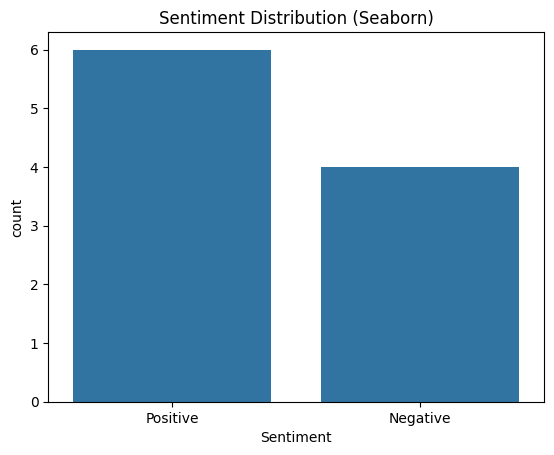

In [9]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution (Seaborn)")
plt.show()